<a href="https://colab.research.google.com/github/Adamphoenix003/GNN-LinkPrediction/blob/main/ppi_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [ ]:
import os

drive_path = '/content/drive/MyDrive/ppi/ppi' # Updated path to look inside the nested 'ppi' directory

# Check if the directory exists
if not os.path.exists(drive_path):
    print(f"The directory '{drive_path}' does not exist.")
else:
    print(f"Contents of '{drive_path}':")
    for item in os.listdir(drive_path):
        item_path = os.path.join(drive_path, item)
        if os.path.isdir(item_path):
            print(f"[DIR] {item}")
        else:
            print(f"[FILE] {item}")

Contents of '/content/drive/MyDrive/ppi/ppi':
[FILE] ppi-feats.npy
[FILE] ppi-class_map.json
[FILE] ppi-G.json
[FILE] ppi-id_map.json
[FILE] ppi-walks.txt


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GraphSAGE_Mean(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()

        self.fc1 = nn.Linear(in_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim * 2, out_dim)

    def aggregate(self, x, adj):
        return torch.matmul(adj, x)

    def forward(self, x, adj):

        neigh = self.aggregate(x, adj)
        h = torch.cat([x, neigh], dim=1)
        h = F.relu(self.fc1(h))

        neigh = self.aggregate(h, adj)
        h = torch.cat([h, neigh], dim=1)
        h = self.fc2(h)

        return h

In [ ]:
class GraphSAGE_GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()

        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, out_dim)

    def aggregate(self, x, adj):
        return torch.matmul(adj, x)

    def forward(self, x, adj):

        h = self.aggregate(x, adj)
        h = F.relu(self.fc1(h))

        h = self.aggregate(h, adj)
        h = self.fc2(h)

        return h

In [ ]:
import numpy as np
import json
import torch
import scipy.sparse # Import scipy.sparse for efficient degree calculation

data_dir = "/content/drive/MyDrive/ppi/ppi"

# features
features = np.load(f"{data_dir}/ppi-feats.npy")

# graph
with open(f"{data_dir}/ppi-G.json") as f:
    graph = json.load(f)

# id map
with open(f"{data_dir}/ppi-id_map.json") as f:
    id_map = json.load(f)

# labels
with open(f"{data_dir}/ppi-class_map.json") as f:
    class_map = json.load(f)

print("features shape:", features.shape)

num_nodes = len(id_map)

# --- Sparse Adjacency Matrix Construction and Normalization ---
row_indices = []
col_indices = []
degrees = np.zeros(num_nodes, dtype=np.float32)

# Collect edges and calculate degrees
for edge in graph["links"]:
    src = id_map[str(edge["source"])]
    dst = id_map[str(edge["target"])]

    # Add both directions for an undirected graph
    row_indices.append(src)
    col_indices.append(dst)
    degrees[src] += 1

    row_indices.append(dst)
    col_indices.append(src)
    degrees[dst] += 1

# Calculate inverse degrees for normalization: 1/degree
inv_degrees = np.where(degrees > 0, 1.0 / degrees, 0.0)

# Apply normalization to the data values
# Each entry (row_idx, col_idx) will have a value of 1/degree[row_idx]
normalized_values = [inv_degrees[row_indices[k]] for k in range(len(row_indices))]

# Create sparse COO tensor
adj_indices = torch.tensor([row_indices, col_indices], dtype=torch.long)
adj_values = torch.tensor(normalized_values, dtype=torch.float32)

# Ensure the sparse tensor is created correctly with the specified size
adj = torch.sparse_coo_tensor(adj_indices, adj_values, (num_nodes, num_nodes), dtype=torch.float32)

# Coalesce to handle potential duplicate entries (though not expected here with simple undirected graph)
adj = adj.coalesce()
# --- End Sparse Adjacency Matrix Construction and Normalization ---

num_classes = len(next(iter(class_map.values())))

labels = np.zeros((num_nodes, num_classes))

for node, label in class_map.items():
    labels[id_map[node]] = label

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

features = torch.tensor(features, dtype=torch.float32).to(device)
adj = adj.to(device) # Move sparse tensor to device
labels = torch.tensor(labels, dtype=torch.float32).to(device)

print("Features shape:", features.shape)
print("Adj shape:", adj.shape, "(sparse tensor)")
print("Labels shape:", labels.shape)


features shape: (56944, 50)
Features shape: torch.Size([56944, 50])
Adj shape: torch.Size([56944, 56944]) (sparse tensor)
Labels shape: torch.Size([56944, 121])


In [ ]:
model = GraphSAGE_Mean(
    in_dim=features.shape[1],
    hidden_dim=128,
    out_dim=labels.shape[1]
).to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

mean_losses = []
mean_accuracies = []

for epoch in range(200):

    model.train()

    out = model(features, adj)

    loss = torch.nn.functional.binary_cross_entropy_with_logits(
        out, labels
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Calculate accuracy
    # Apply sigmoid to logits to get probabilities
    probabilities = torch.sigmoid(out)
    # Threshold probabilities to get binary predictions
    predictions = (probabilities > 0.5).float()
    # Calculate element-wise equality and sum up correct predictions
    correct_predictions = (predictions == labels).float().sum()
    # Total number of labels
    total_labels = labels.numel()
    # Calculate accuracy as a percentage of correctly predicted individual labels
    accuracy = (correct_predictions / total_labels).item()

    mean_losses.append(loss.item())
    mean_accuracies.append(accuracy)

    print(f"Epoch {epoch} | Loss {loss.item():.4f} | Accuracy {accuracy:.4f}")

Epoch 0 | Loss 0.5468 | Accuracy 0.7409
Epoch 1 | Loss 0.5467 | Accuracy 0.7409
Epoch 2 | Loss 0.5467 | Accuracy 0.7410
Epoch 3 | Loss 0.5466 | Accuracy 0.7410
Epoch 4 | Loss 0.5465 | Accuracy 0.7410
Epoch 5 | Loss 0.5464 | Accuracy 0.7410
Epoch 6 | Loss 0.5463 | Accuracy 0.7410
Epoch 7 | Loss 0.5462 | Accuracy 0.7410
Epoch 8 | Loss 0.5461 | Accuracy 0.7411
Epoch 9 | Loss 0.5460 | Accuracy 0.7411
Epoch 10 | Loss 0.5459 | Accuracy 0.7411
Epoch 11 | Loss 0.5458 | Accuracy 0.7411
Epoch 12 | Loss 0.5457 | Accuracy 0.7411
Epoch 13 | Loss 0.5456 | Accuracy 0.7411
Epoch 14 | Loss 0.5456 | Accuracy 0.7412
Epoch 15 | Loss 0.5455 | Accuracy 0.7412
Epoch 16 | Loss 0.5454 | Accuracy 0.7412
Epoch 17 | Loss 0.5453 | Accuracy 0.7412
Epoch 18 | Loss 0.5452 | Accuracy 0.7413
Epoch 19 | Loss 0.5451 | Accuracy 0.7413
Epoch 20 | Loss 0.5450 | Accuracy 0.7413
Epoch 21 | Loss 0.5449 | Accuracy 0.7413
Epoch 22 | Loss 0.5448 | Accuracy 0.7413
Epoch 23 | Loss 0.5447 | Accuracy 0.7413
Epoch 24 | Loss 0.5446 | A

In [ ]:
model = GraphSAGE_GCN(
    in_dim=features.shape[1],
    hidden_dim=128,
    out_dim=labels.shape[1]
).to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

gcn_losses = []
gcn_accuracies = []

for epoch in range(200):

    model.train()

    out = model(features, adj)

    loss = torch.nn.functional.binary_cross_entropy_with_logits(
        out, labels
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Calculate accuracy
    # Apply sigmoid to logits to get probabilities
    probabilities = torch.sigmoid(out)
    # Threshold probabilities to get binary predictions
    predictions = (probabilities > 0.5).float()
    # Calculate element-wise equality and sum up correct predictions
    correct_predictions = (predictions == labels).float().sum()
    # Total number of labels
    total_labels = labels.numel()
    # Calculate accuracy as a percentage of correctly predicted individual labels
    accuracy = (correct_predictions / total_labels).item()

    gcn_losses.append(loss.item())
    gcn_accuracies.append(accuracy)

    print(f"Epoch {epoch} | Loss {loss.item():.4f} | Accuracy {accuracy:.4f}")

Epoch 0 | Loss 0.5278 | Accuracy 0.7457
Epoch 1 | Loss 0.5277 | Accuracy 0.7457
Epoch 2 | Loss 0.5277 | Accuracy 0.7457
Epoch 3 | Loss 0.5276 | Accuracy 0.7457
Epoch 4 | Loss 0.5275 | Accuracy 0.7457
Epoch 5 | Loss 0.5275 | Accuracy 0.7458
Epoch 6 | Loss 0.5274 | Accuracy 0.7458
Epoch 7 | Loss 0.5273 | Accuracy 0.7458
Epoch 8 | Loss 0.5273 | Accuracy 0.7458
Epoch 9 | Loss 0.5272 | Accuracy 0.7458
Epoch 10 | Loss 0.5272 | Accuracy 0.7459
Epoch 11 | Loss 0.5271 | Accuracy 0.7459
Epoch 12 | Loss 0.5270 | Accuracy 0.7459
Epoch 13 | Loss 0.5270 | Accuracy 0.7459
Epoch 14 | Loss 0.5269 | Accuracy 0.7459
Epoch 15 | Loss 0.5269 | Accuracy 0.7459
Epoch 16 | Loss 0.5268 | Accuracy 0.7459
Epoch 17 | Loss 0.5267 | Accuracy 0.7459
Epoch 18 | Loss 0.5267 | Accuracy 0.7459
Epoch 19 | Loss 0.5266 | Accuracy 0.7460
Epoch 20 | Loss 0.5266 | Accuracy 0.7460
Epoch 21 | Loss 0.5265 | Accuracy 0.7460
Epoch 22 | Loss 0.5264 | Accuracy 0.7460
Epoch 23 | Loss 0.5264 | Accuracy 0.7460
Epoch 24 | Loss 0.5263 | A

In [ ]:
from sklearn.metrics import f1_score

# Re-instantiate the GraphSAGE_Mean model for F1 calculation
model_mean_f1 = GraphSAGE_Mean(
    in_dim=features.shape[1],
    hidden_dim=128,
    out_dim=labels.shape[1]
).to(device)

optimizer_mean_f1 = torch.optim.Adam(model_mean_f1.parameters(), lr=0.001)

mean_f1_scores = []

for epoch in range(200):
    model_mean_f1.train()
    out_mean = model_mean_f1(features, adj)
    loss_mean = torch.nn.functional.binary_cross_entropy_with_logits(out_mean, labels)
    optimizer_mean_f1.zero_grad()
    loss_mean.backward()
    optimizer_mean_f1.step()

    probabilities_mean = torch.sigmoid(out_mean)
    predictions_mean = (probabilities_mean > 0.5).float()

    # Calculate F1 Score (micro average for multi-label classification)
    f1_mean = f1_score(labels.cpu().numpy(), predictions_mean.cpu().numpy(), average='micro')
    mean_f1_scores.append(f1_mean)

    if epoch % 20 == 0:
        print(f"Epoch {epoch} (Mean) | Loss {loss_mean.item():.4f} | F1 Score {f1_mean:.4f}")

final_f1_mean = mean_f1_scores[-1]
print(f"\nFinal Micro-averaged F1 Score for GraphSAGE_Mean: {final_f1_mean:.4f}")

Epoch 0 (Mean) | Loss 0.6940 | F1 Score 0.3736
Epoch 20 (Mean) | Loss 0.6281 | F1 Score 0.3949
Epoch 40 (Mean) | Loss 0.5652 | F1 Score 0.3931
Epoch 60 (Mean) | Loss 0.5557 | F1 Score 0.3954
Epoch 80 (Mean) | Loss 0.5518 | F1 Score 0.3990
Epoch 100 (Mean) | Loss 0.5489 | F1 Score 0.4043
Epoch 120 (Mean) | Loss 0.5459 | F1 Score 0.4101
Epoch 140 (Mean) | Loss 0.5428 | F1 Score 0.4163
Epoch 160 (Mean) | Loss 0.5398 | F1 Score 0.4231
Epoch 180 (Mean) | Loss 0.5371 | F1 Score 0.4301

Final Micro-averaged F1 Score for GraphSAGE_Mean: 0.4359


In [ ]:
from sklearn.metrics import f1_score

# Re-instantiate the GraphSAGE_GCN model for F1 calculation
model_gcn_f1 = GraphSAGE_GCN(
    in_dim=features.shape[1],
    hidden_dim=128,
    out_dim=labels.shape[1]
).to(device)

optimizer_gcn_f1 = torch.optim.Adam(model_gcn_f1.parameters(), lr=0.001)

gcn_f1_scores = []

for epoch in range(200):
    model_gcn_f1.train()
    out_gcn = model_gcn_f1(features, adj)
    loss_gcn = torch.nn.functional.binary_cross_entropy_with_logits(out_gcn, labels)
    optimizer_gcn_f1.zero_grad()
    loss_gcn.backward()
    optimizer_gcn_f1.step()

    probabilities_gcn = torch.sigmoid(out_gcn)
    predictions_gcn = (probabilities_gcn > 0.5).float()

    # Calculate F1 Score (micro average for multi-label classification)
    f1_gcn = f1_score(labels.cpu().numpy(), predictions_gcn.cpu().numpy(), average='micro')
    gcn_f1_scores.append(f1_gcn)

    if epoch % 20 == 0:
        print(f"Epoch {epoch} (GCN) | Loss {loss_gcn.item():.4f} | F1 Score {f1_gcn:.4f}")

final_f1_gcn = gcn_f1_scores[-1]
print(f"\nFinal Micro-averaged F1 Score for GraphSAGE_GCN: {final_f1_gcn:.4f}")

Epoch 0 (GCN) | Loss 0.6914 | F1 Score 0.3576
Epoch 20 (GCN) | Loss 0.6538 | F1 Score 0.3914
Epoch 40 (GCN) | Loss 0.5988 | F1 Score 0.3913
Epoch 60 (GCN) | Loss 0.5593 | F1 Score 0.3923
Epoch 80 (GCN) | Loss 0.5527 | F1 Score 0.3930
Epoch 100 (GCN) | Loss 0.5513 | F1 Score 0.3931
Epoch 120 (GCN) | Loss 0.5507 | F1 Score 0.3929
Epoch 140 (GCN) | Loss 0.5500 | F1 Score 0.3925
Epoch 160 (GCN) | Loss 0.5490 | F1 Score 0.3925
Epoch 180 (GCN) | Loss 0.5479 | F1 Score 0.3932

Final Micro-averaged F1 Score for GraphSAGE_GCN: 0.3953


In [ ]:
print(f"Final Micro-averaged F1 Score for GraphSAGE_Mean: {final_f1_mean:.4f}")
print(f"Final Micro-averaged F1 Score for GraphSAGE_GCN: {final_f1_gcn:.4f}")

Final Micro-averaged F1 Score for GraphSAGE_Mean: 0.4359
Final Micro-averaged F1 Score for GraphSAGE_GCN: 0.3953


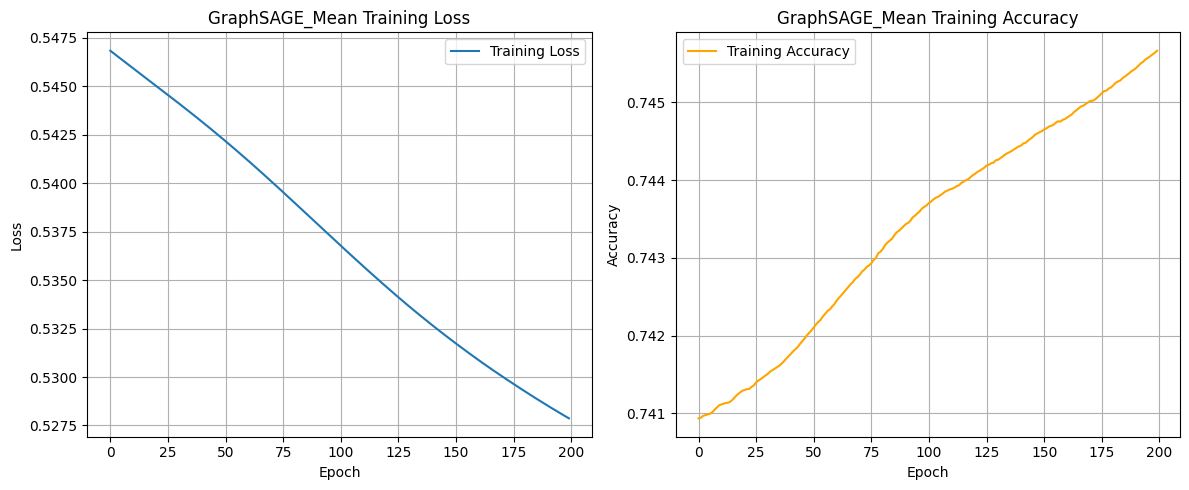

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plotting loss for GraphSAGE_Mean
plt.subplot(1, 2, 1)
plt.plot(mean_losses, label='Training Loss')
plt.title('GraphSAGE_Mean Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting accuracy for GraphSAGE_Mean
plt.subplot(1, 2, 2)
plt.plot(mean_accuracies, label='Training Accuracy', color='orange')
plt.title('GraphSAGE_Mean Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

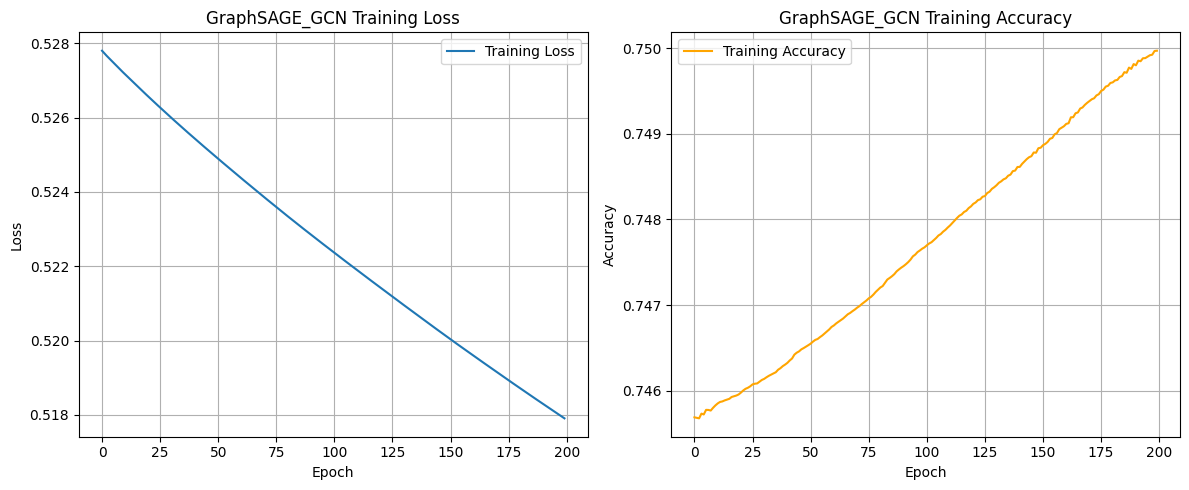

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plotting loss for GraphSAGE_GCN
plt.subplot(1, 2, 1)
plt.plot(gcn_losses, label='Training Loss')
plt.title('GraphSAGE_GCN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting accuracy for GraphSAGE_GCN
plt.subplot(1, 2, 2)
plt.plot(gcn_accuracies, label='Training Accuracy', color='orange')
plt.title('GraphSAGE_GCN Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()